# **Dry Bean Classification | K - Dimentional Tree**

Classification types of Dry Bean using K - Dimentional Tree algoritm.

## 1. Data Understanding

### 1.1 Import Library 

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 
import tkinter as tk

from tkinter import messagebox

### 1.2 Read Dataset

In [2]:
# Import 'Dry_Bean_Dataset.xlsx'
beanx = pd.read_excel('Dry_Bean_Dataset.xlsx')
bean = beanx.to_csv('Dry_Bean_Dataset.csv')
bean = pd.read_csv('Dry_Bean_Dataset.csv')

In [3]:
# Show 5 top of dataset 
print('\nTop 5 rows of dataset:')
bean.head()


Top 5 rows of dataset:


,Unnamed: 0,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272750,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [4]:
# Show the information of dataset
print('\nInformation of dataset:')
bean.info()


Information of dataset:
<class 'pandas.DataFrame'>
RangeIndex: 13611 entries, 0 to 13610
Data columns (total 18 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Unnamed: 0       13611 non-null  int64  
 1   Area             13611 non-null  int64  
 2   Perimeter        13611 non-null  float64
 3   MajorAxisLength  13611 non-null  float64
 4   MinorAxisLength  13611 non-null  float64
 5   AspectRation     13611 non-null  float64
 6   Eccentricity     13611 non-null  float64
 7   ConvexArea       13611 non-null  int64  
 8   EquivDiameter    13611 non-null  float64
 9   Extent           13611 non-null  float64
 10  Solidity         13611 non-null  float64
 11  roundness        13611 non-null  float64
 12  Compactness      13611 non-null  float64
 13  ShapeFactor1     13611 non-null  float64
 14  ShapeFactor2     13611 non-null  float64
 15  ShapeFactor3     13611 non-null  float64
 16  ShapeFactor4     13611 non-null  float64
 17

In [5]:
# Show the dimensional data
print('\nDimesional data:')
print('Number of rows:', bean.shape[0])
print('Number of columns:', bean.shape[1])


Dimesional data:
Number of rows: 13611
Number of columns: 18


In [6]:
# Show the number of unique values per columns
print('\nNumber of unique values:')
bean.nunique()


Number of unique values:


Unnamed: 0         13611
Area               12011
Perimeter          13413
MajorAxisLength    13543
MinorAxisLength    13543
AspectRation       13543
Eccentricity       13543
ConvexArea         12066
EquivDiameter      12011
Extent             13535
Solidity           13526
roundness          13543
Compactness        13543
ShapeFactor1       13543
ShapeFactor2       13543
ShapeFactor3       13543
ShapeFactor4       13543
Class                  7
dtype: int64

In [7]:
# Drop the 'Unnamed: 0' columns
bean = bean.drop('Unnamed: 0', axis=1)

# Checking the columns of dataset 
bean.columns

Index(['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
       'AspectRation', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent',
       'Solidity', 'roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2',
       'ShapeFactor3', 'ShapeFactor4', 'Class'],
      dtype='str')

In [8]:
# Show the number of missing values of dataset
print('\nNumber of missing values:', bean.isnull().sum().sum())

# Show the number of duplicated data of dataset
print('\nNumber of duplicated rows:', bean.duplicated().sum())


Number of missing values: 0



Number of duplicated rows: 68


In [9]:
# Show the rows that have a duplicated data
print('Show the rows that have a duplicated data:')
bean[bean.duplicated(keep=False)]

Show the rows that have a duplicated data:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
5504,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5505,33518,702.956,277.571399,154.305581,1.798842,0.831240,34023,206.582775,0.808383,0.985157,0.852377,0.744251,0.008281,0.001567,0.553909,0.996396,HOROZ
5508,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5509,33954,716.750,277.368480,156.356326,1.773951,0.825970,34420,207.922042,0.799482,0.986461,0.830549,0.749624,0.008169,0.001591,0.561936,0.996847,HOROZ
5547,38427,756.323,306.533886,160.591784,1.908777,0.851782,38773,221.193978,0.796976,0.991076,0.844174,0.721597,0.007977,0.001334,0.520702,0.993905,HOROZ
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7285,63948,996.497,412.297178,198.877557,2.073121,0.875971,64641,285.343867,0.777909,0.989279,0.809254,0.692083,0.006447,0.000912,0.478979,0.992981,HOROZ
7339,65766,1035.842,406.416622,207.242369,1.961069,0.860218,66698,289.371512,0.792295,0.986027,0.770237,0.712007,0.006180,0.000980,0.506954,0.994172,HOROZ
7340,65766,1035.842,406.416622,207.242369,1.961069,0.860218,66698,289.371512,0.792295,0.986027,0.770237,0.712007,0.006180,0.000980,0.506954,0.994172,HOROZ
7341,65781,1039.257,409.713859,204.992832,1.998674,0.865834,66762,289.404510,0.642549,0.985306,0.765358,0.706358,0.006228,0.000956,0.498941,0.997221,HOROZ


In [10]:
# Separate numerical & categorical features
num_cols = bean.drop('Class', axis=1)
cat_cols = bean['Class']

## 2. Exploratory Data Analysis

### 2.1 Multivariate Analysis 

#### Statistical Analysis

In [11]:
# Statistical summary of dataset 
print('\nStatistical sumaary of dataset:')
bean.describe()


Statistical sumaary of dataset:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRation,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860153,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


- **Insight**:
1. Beberapa fitur memiliki nilai standart deviation yang tinggi. Itu berarti, nilai unik pada fitur tersebut, data tersebar luas dari rata-ratanya. Contoh: Area, ConvexArea.
2. Beberapa fitur memiliki selisih nilai yang jauh antara median dengan nilai tertinggi (max) Contoh: Area, MajorAxisLength. Itu berarti, fitur tersebut ada kemungkinan memiliki outlier yang harus ditangani.



#### Correlation Analysis

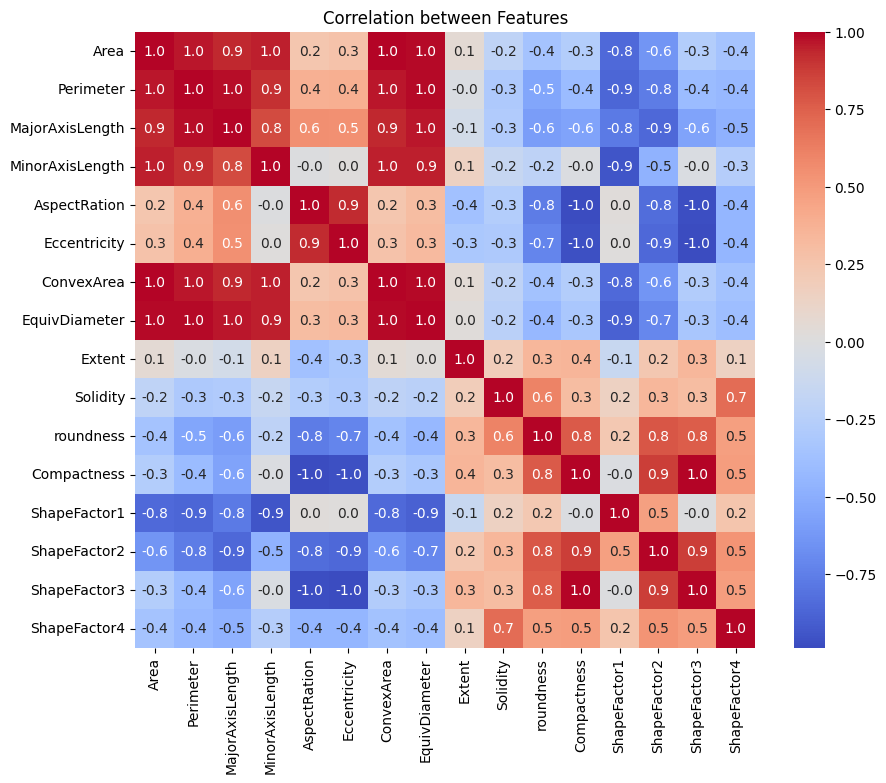

In [12]:
# Show the correlation of dataset
correlation = num_cols.corr()

# Visualization
plt.figure(figsize=(10,8))
sns.heatmap(correlation, annot=True, cmap='coolwarm', fmt='.1f')
plt.title('Correlation between Features')
plt.show()

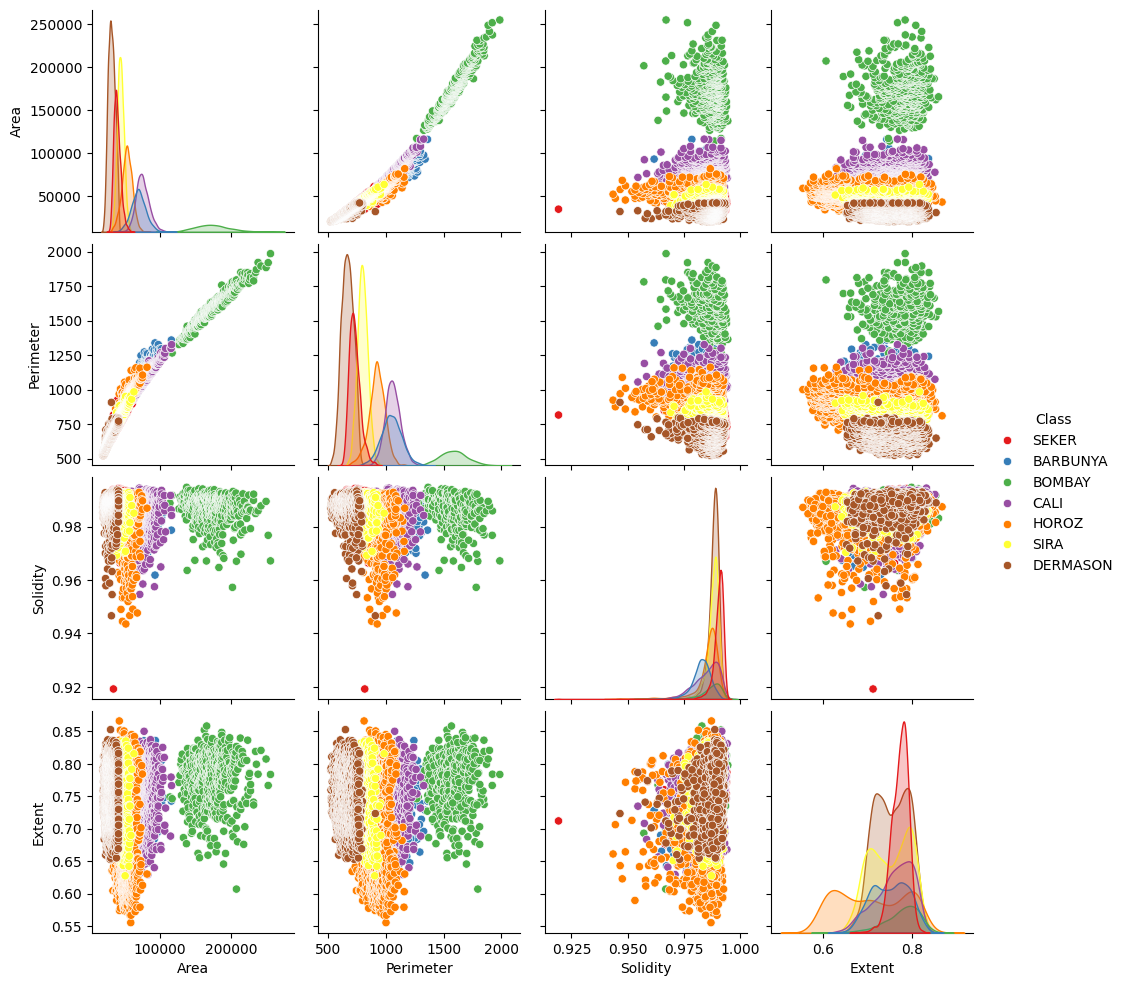

In [13]:
# Ambil beberapa fitur utama saja agar tidak berat saat plotting
sns.pairplot(bean, vars=['Area', 'Perimeter', 'Solidity', 'Extent'], hue='Class', palette='Set1')
plt.show()

### 2.2 Univariate Analysis

#### Distribution Analysis

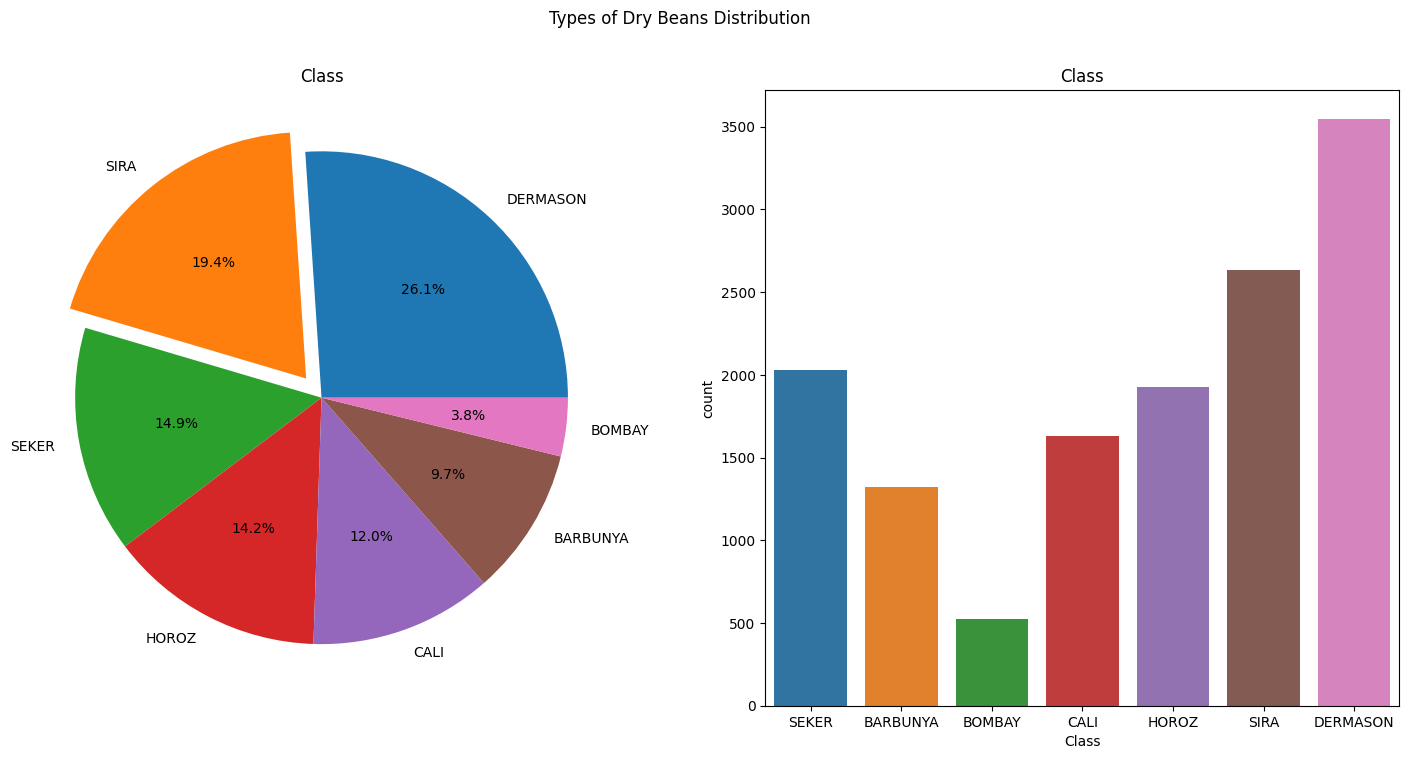

In [14]:
# bean['Class'].value_counts().plot(kind='pie', autopct='%1.1f%%',title='Types of Dry Bean Distribution')

f,ax=plt.subplots(1,2,figsize=(18,8))
bean['Class'].value_counts().plot.pie(explode=[0,0.1,0,0,0,0,0],autopct='%1.1f%%',ax=ax[0])
ax[0].set_title('Class')
ax[0].set_ylabel('')
sns.countplot(data=bean,x='Class',ax=ax[1], hue='Class')
ax[1].set_title('Class')
plt.suptitle('Types of Dry Beans Distribution')
plt.show()

In [15]:
# Show the Number of presentase when the target are balance
balance = (100 / 7) 
print(f'balance: {balance:.2f}%')

balance: 14.29%


- **Insight**: 
1. Tipe kacang DERMASON memiliki jumlah yang terbanyak dalam dataset ini. Sedangkan tipe kacang BOMBAY memiliki jumlah paling sedikit. 
2. Penyebaran target immbalance.

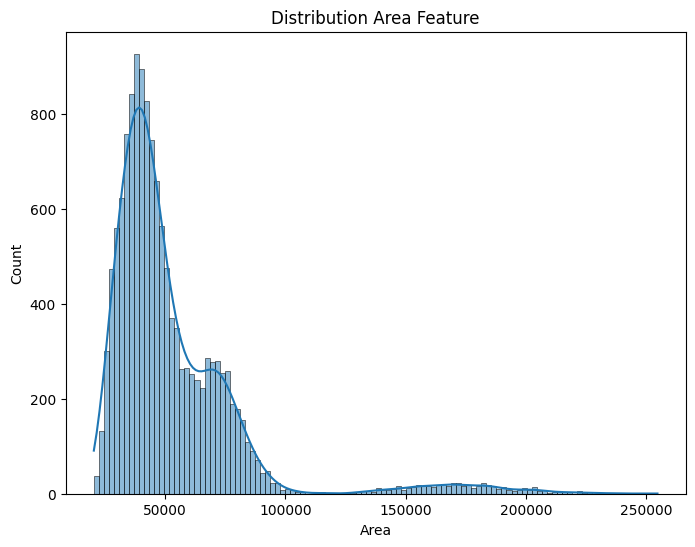

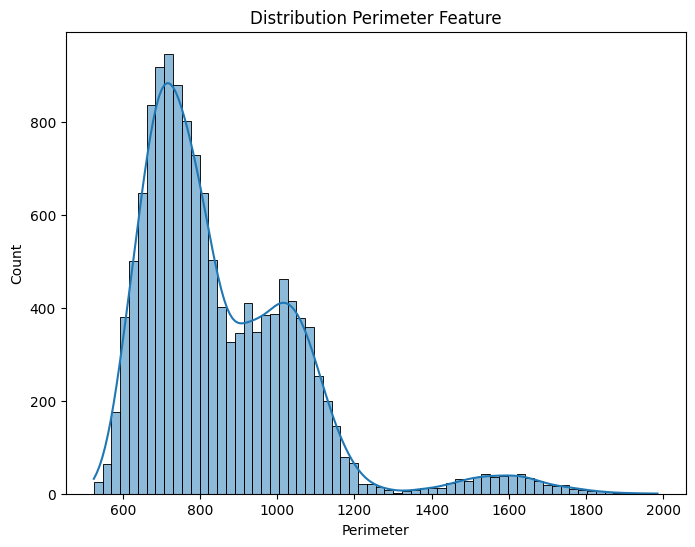

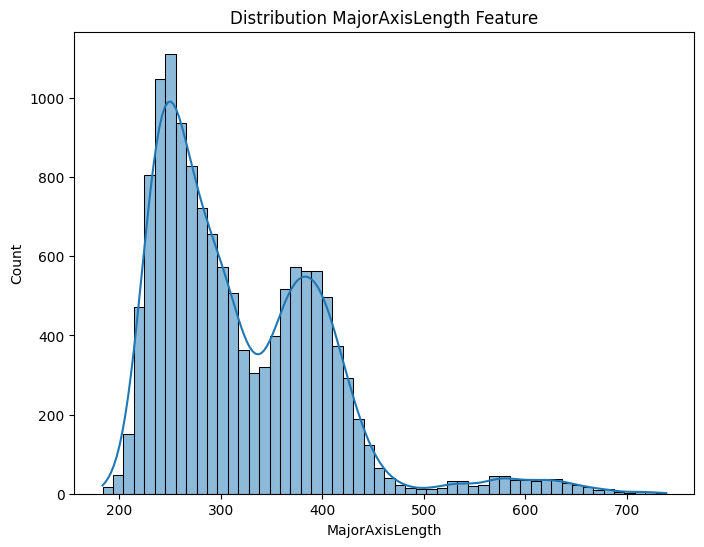

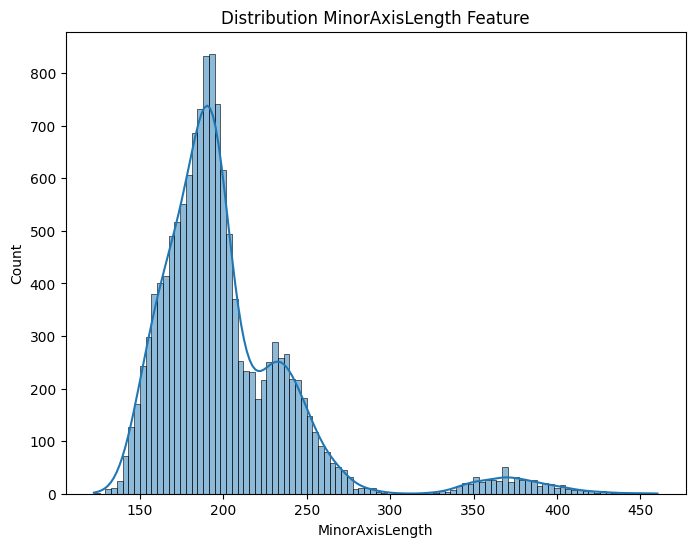

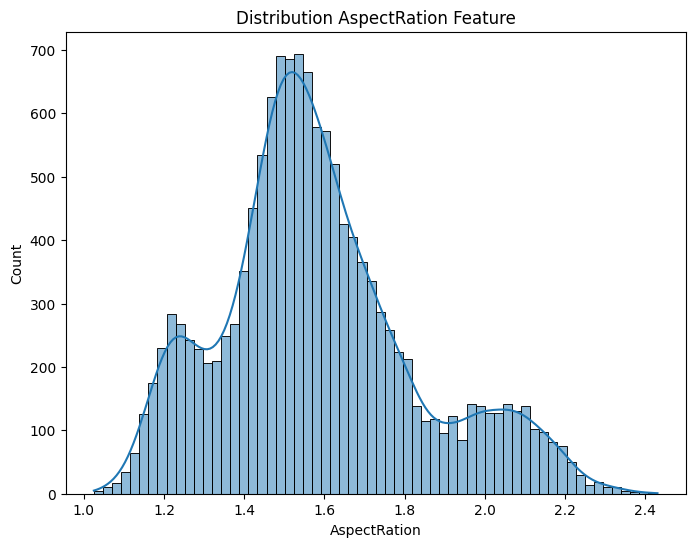

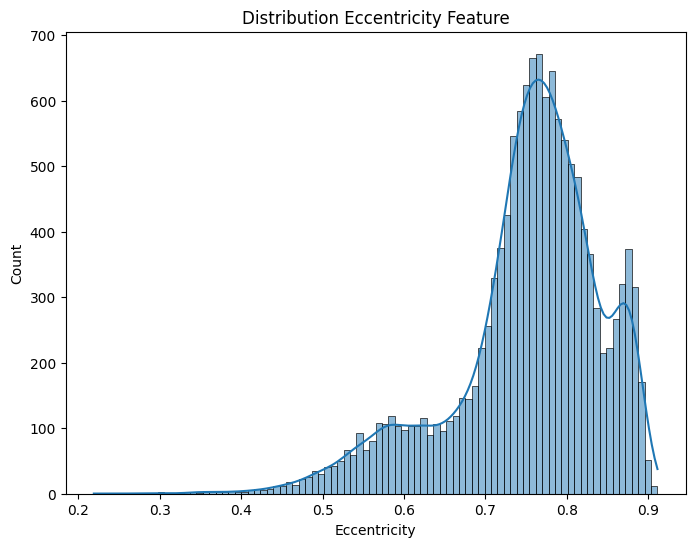

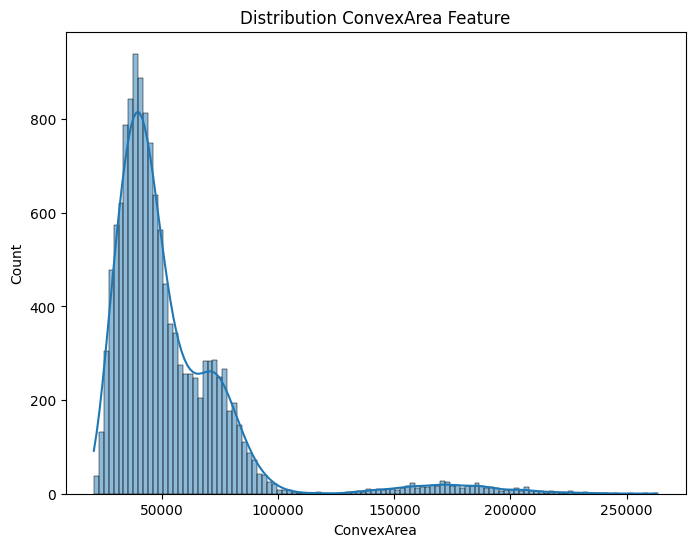

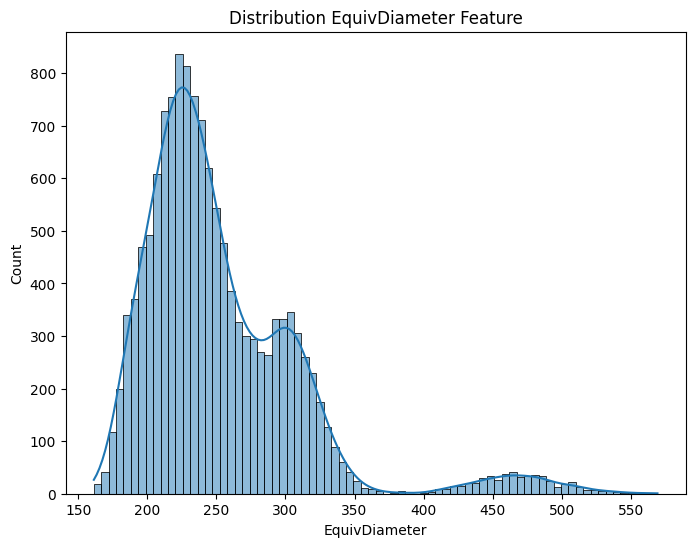

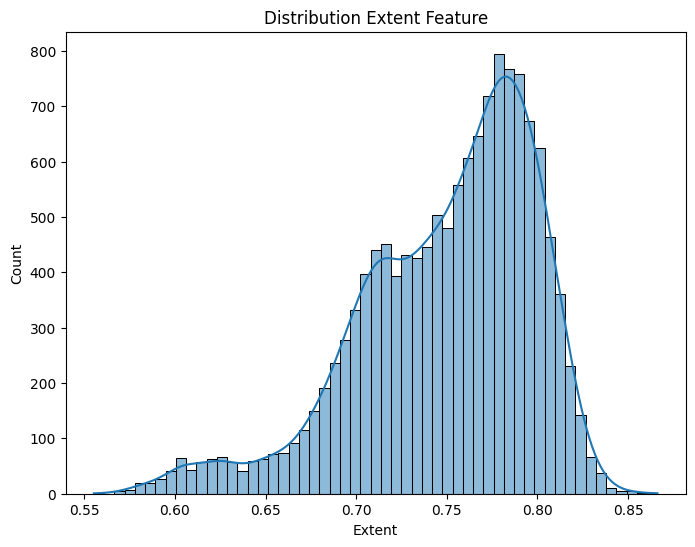

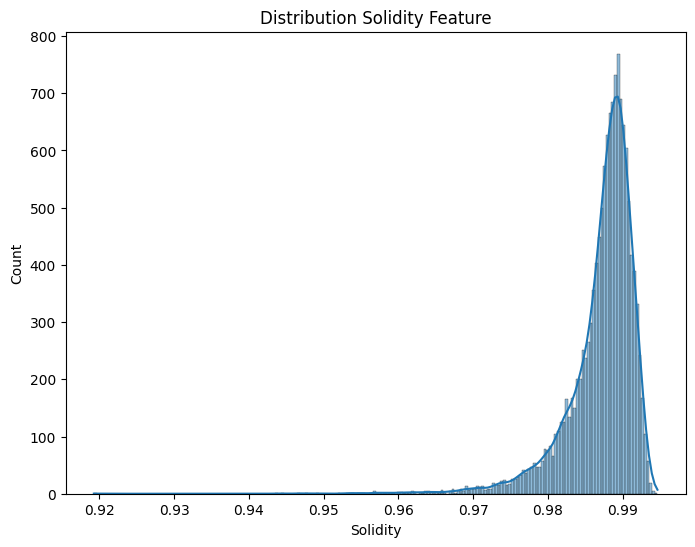

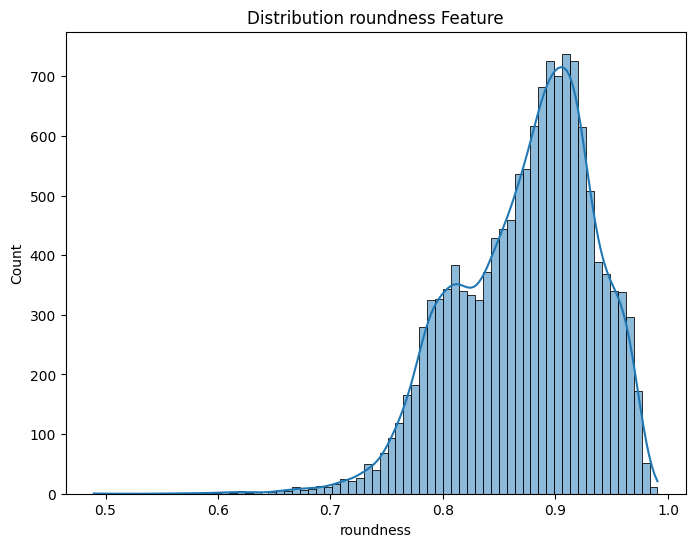

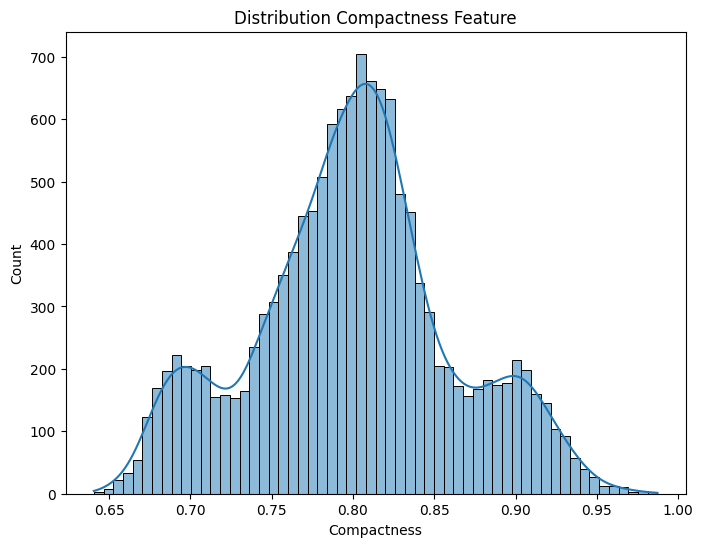

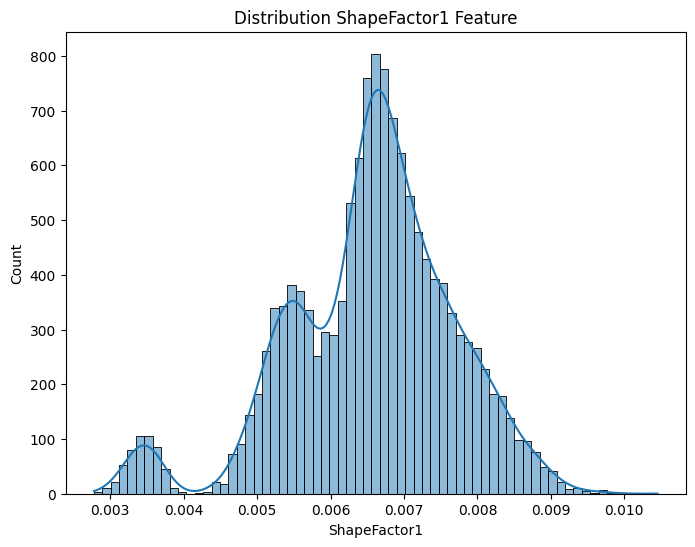

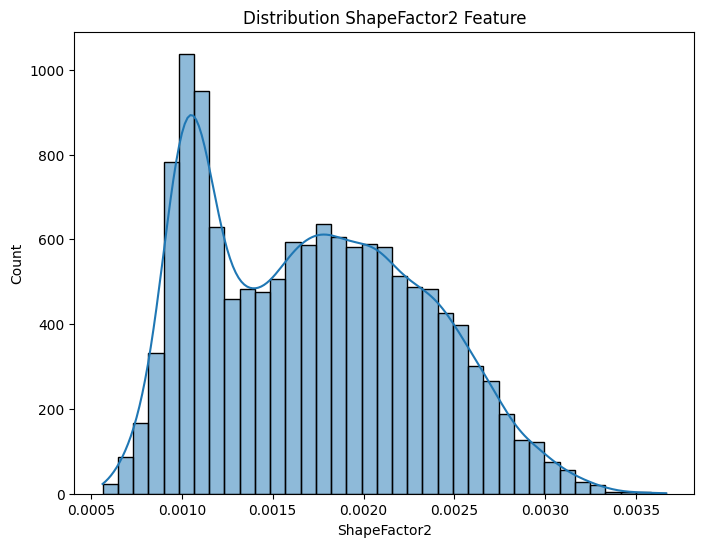

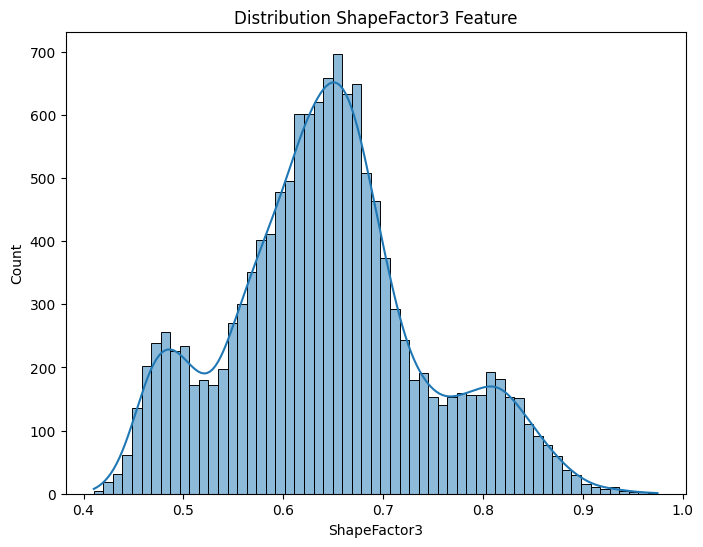

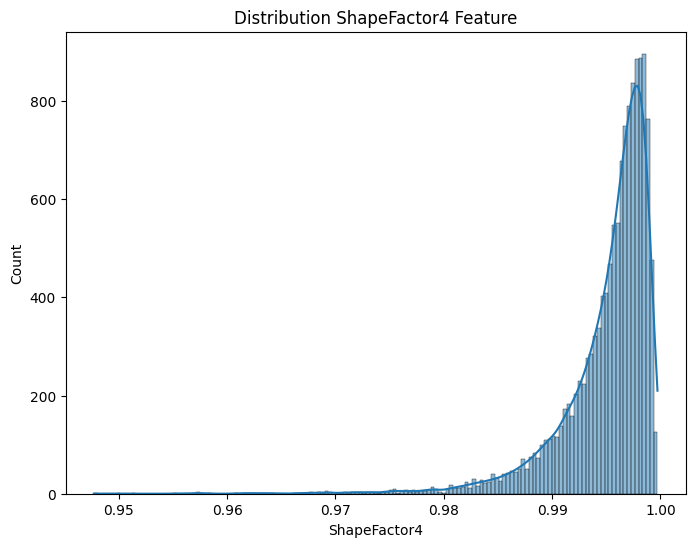

In [16]:
# Show boxplot visualization
for col in num_cols:
    plt.figure(figsize=(8, 6))
    sns.histplot(data=num_cols, x=col, kde=True)
    plt.title(f'Distribution {col} Feature')
    plt.show()

#### Range Analysis

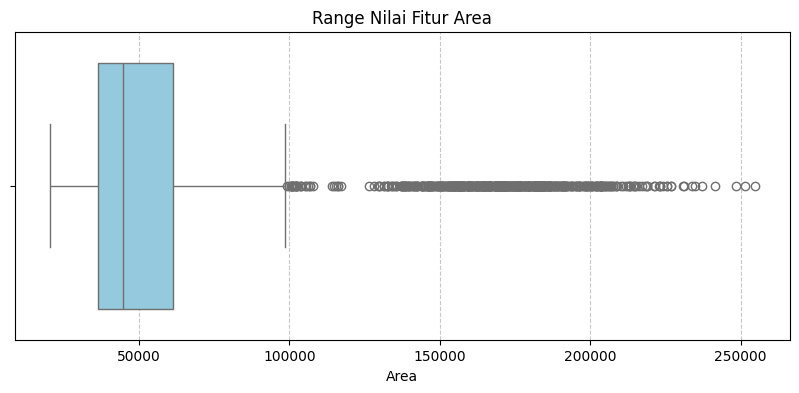

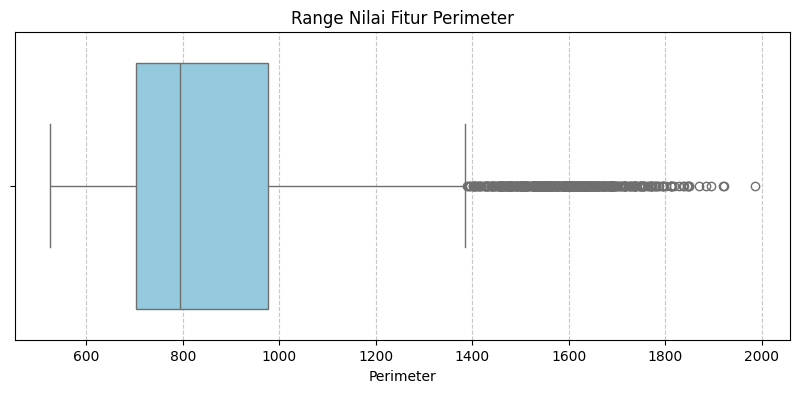

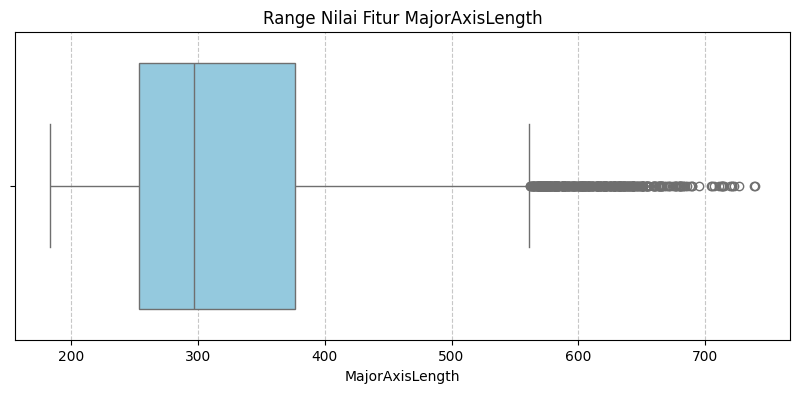

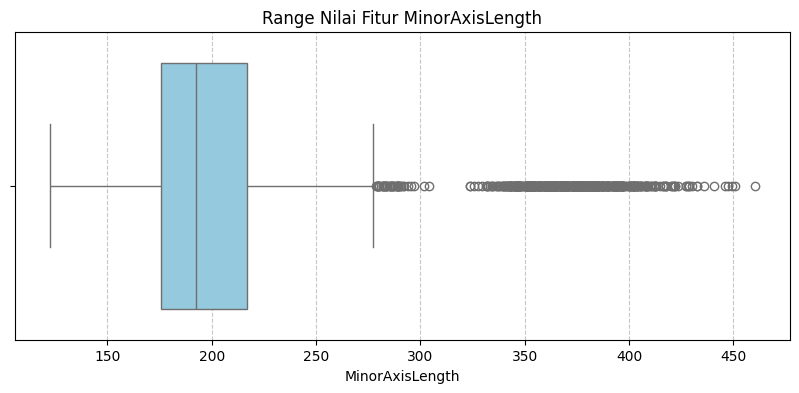

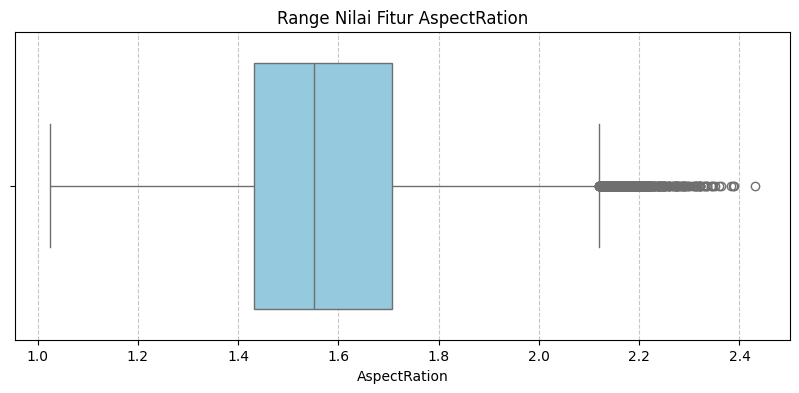

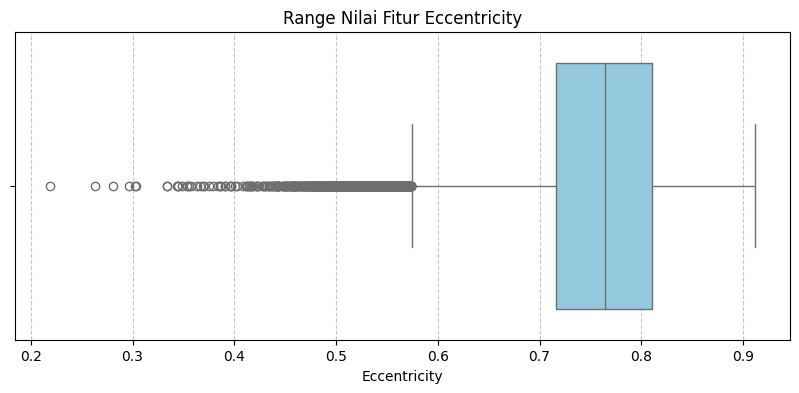

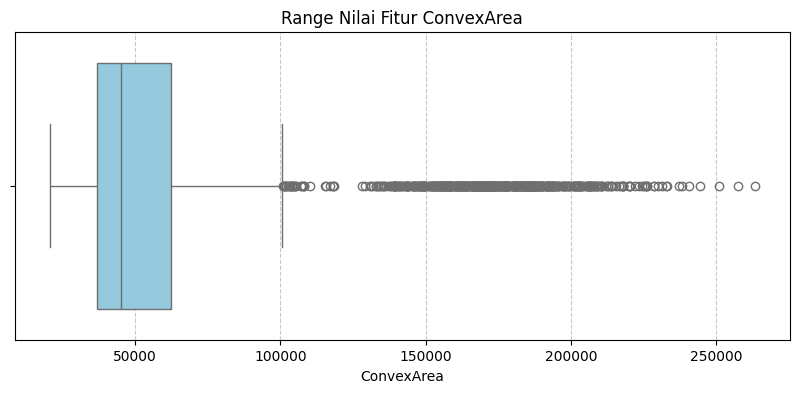

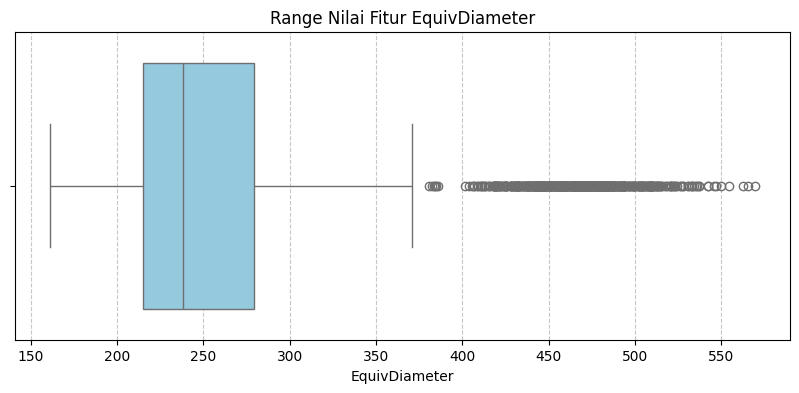

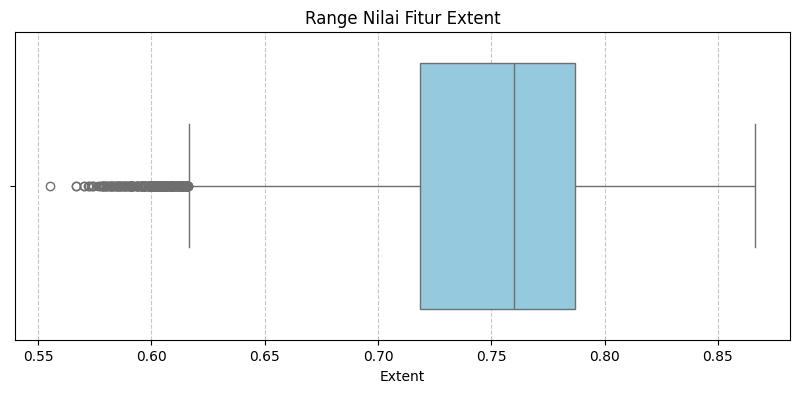

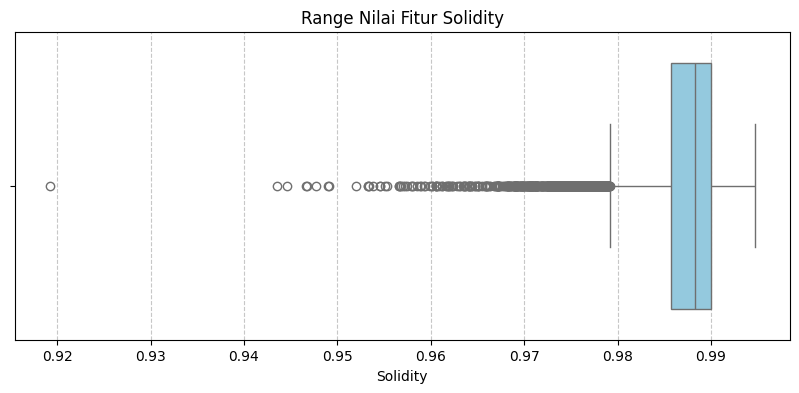

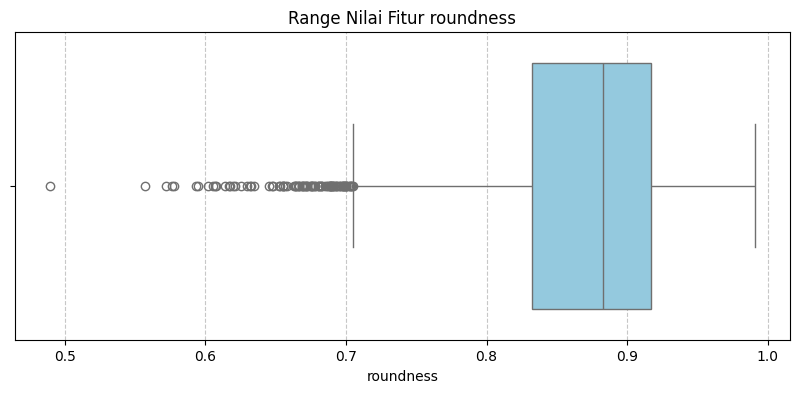

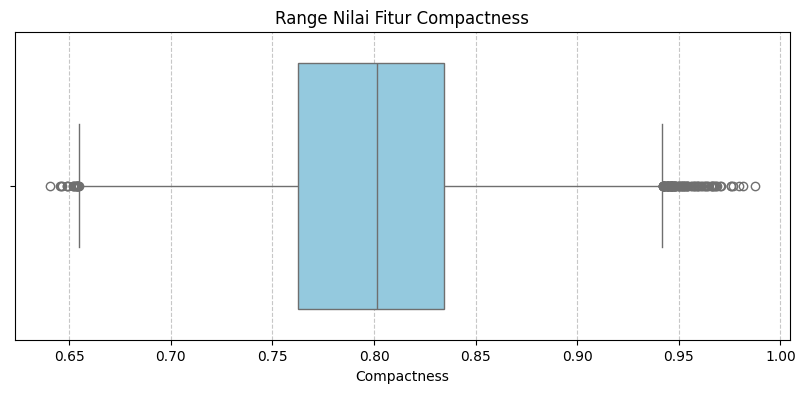

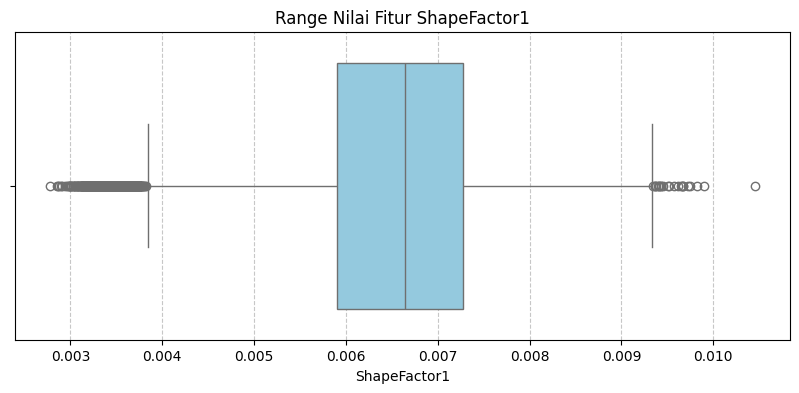

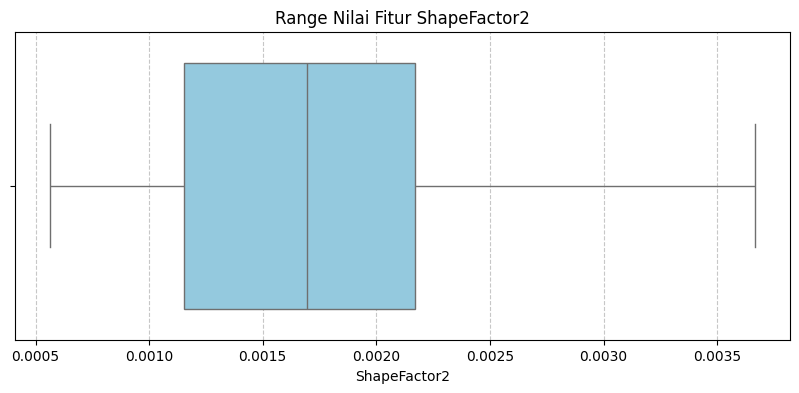

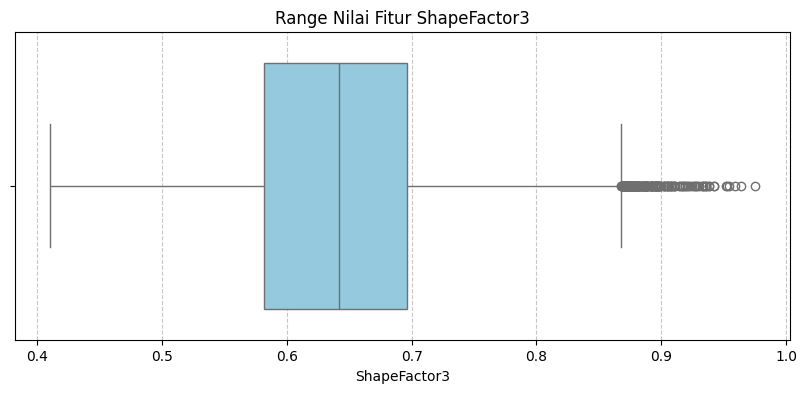

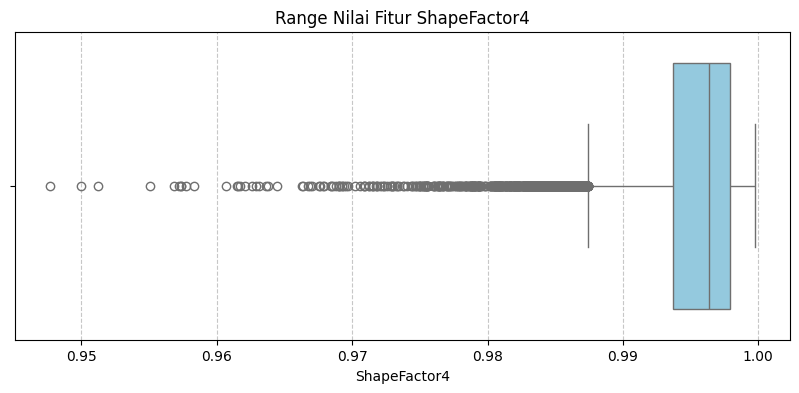

In [17]:
for col in num_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=num_cols[col], color='skyblue') 
    plt.title(f'Range Nilai Fitur {col}')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

## 3. Data Pre-processing

### 3.1 Handling Duplicated Data

In [18]:
# Drop the first rows of duplicated data
bean = bean.drop_duplicates(keep='last').reset_index(drop=True)

# Show the number of duplicated data 
print('\nNumber of duplicated data:', bean.duplicated().sum())
print('m:', bean.isnull().sum().sum())


Number of duplicated data: 0
m: 0


### 3.2 Feature selection

In [19]:
curr_num = bean.drop('Class', axis=1)

corr_matrix = curr_num.corr().abs()
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
to_drop = [column for column in upper.columns if any(upper[column] > 0.95)]

# Drop kolom dari bean secara langsung agar Class tidak terpisah
bean = bean.drop(columns=to_drop)
print('m:', bean.isnull().sum())


m: Area            0
AspectRation    0
Eccentricity    0
Extent          0
Solidity        0
roundness       0
ShapeFactor1    0
ShapeFactor2    0
ShapeFactor4    0
Class           0
dtype: int64


### 3.3 Encoding Target Feature

In [20]:
# Encoding using mapping technique
mapping = {'BOMBAY':0, 'BARBUNYA':1, 'CALI':2, 'HOROZ':3, 'SEKER':4, 'SIRA':5, 'DERMASON':6}
bean['Class'] = bean['Class'].map(mapping)
print('m:', bean.isnull().sum())

m: Area            0
AspectRation    0
Eccentricity    0
Extent          0
Solidity        0
roundness       0
ShapeFactor1    0
ShapeFactor2    0
ShapeFactor4    0
Class           0
dtype: int64


### 3.4 Variable Independent & Dependent

In [21]:
X = bean.drop('Class', axis=1)
y = bean['Class']

### 3.6 Handling Outliers

In [22]:
bean.columns

Index(['Area', 'AspectRation', 'Eccentricity', 'Extent', 'Solidity',
       'roundness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor4', 'Class'],
      dtype='str')

In [23]:
X_log = X.apply(np.log1p)
mean = X_log.mean()
std = X_log.std()
X_scaled = (X_log - mean) / std
bean = pd.concat([X_scaled, y.reset_index(drop=True)], axis=1)

print("Statistik setelah Log + Standarisasi pada semua fitur:")
print(bean.describe())

Statistik setelah Log + Standarisasi pada semua fitur:
               Area  AspectRation  Eccentricity        Extent      Solidity  \
count  1.354300e+04  1.354300e+04  1.354300e+04  1.354300e+04  1.354300e+04   
mean  -2.115416e-15 -1.242387e-15 -1.527801e-15 -4.868815e-16  9.452217e-15   
std    1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00  1.000000e+00   
min   -2.078468e+00 -2.551971e+00 -6.644926e+00 -4.142347e+00 -1.481270e+01   
25%   -6.819156e-01 -5.958366e-01 -3.477867e-01 -6.183595e-01 -3.149034e-01   
50%   -1.815453e-01 -8.313247e-02  1.700902e-01  2.165185e-01  2.445850e-01   
75%    5.955129e-01  5.450960e-01  6.414522e-01  7.524612e-01  6.153833e-01   
max    4.051978e+00  3.093337e+00  1.650132e+00  2.284924e+00  1.611640e+00   

          roundness  ShapeFactor1  ShapeFactor2  ShapeFactor4         Class  
count  1.354300e+04  1.354300e+04  1.354300e+04  1.354300e+04  13543.000000  
mean  -4.449090e-15  6.044047e-16  5.036706e-17  9.368272e-15      3.893229  

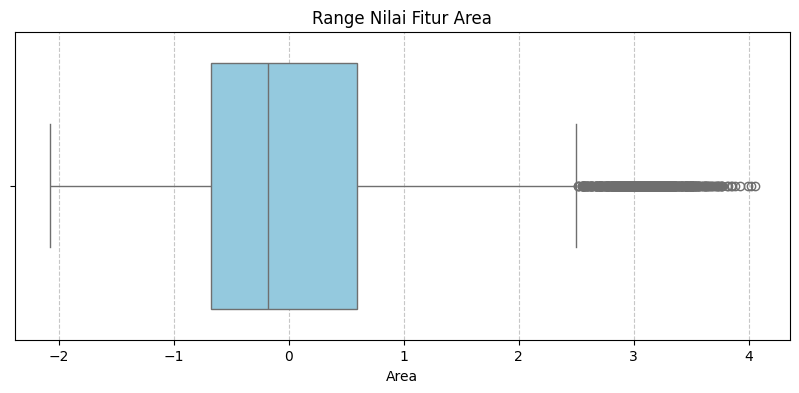

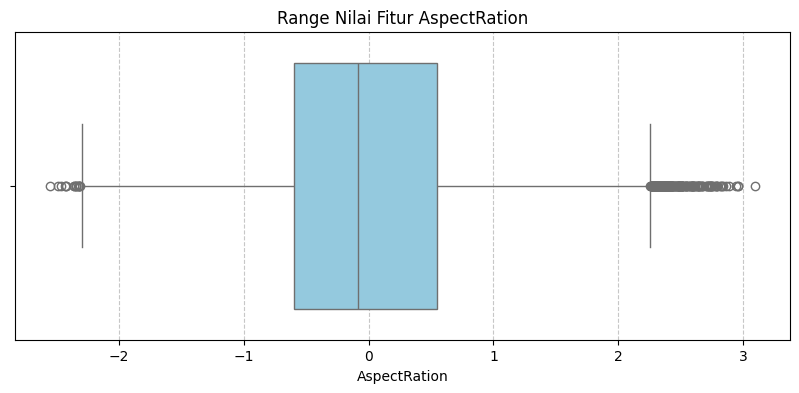

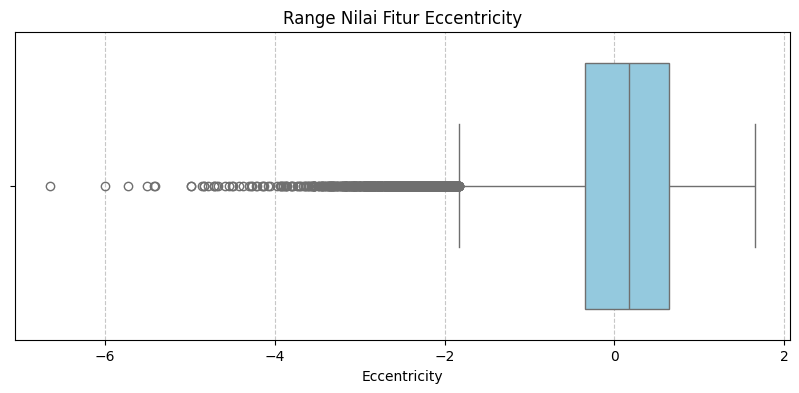

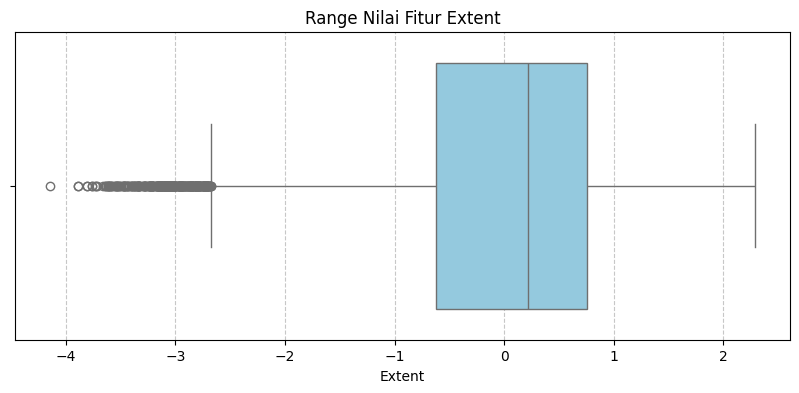

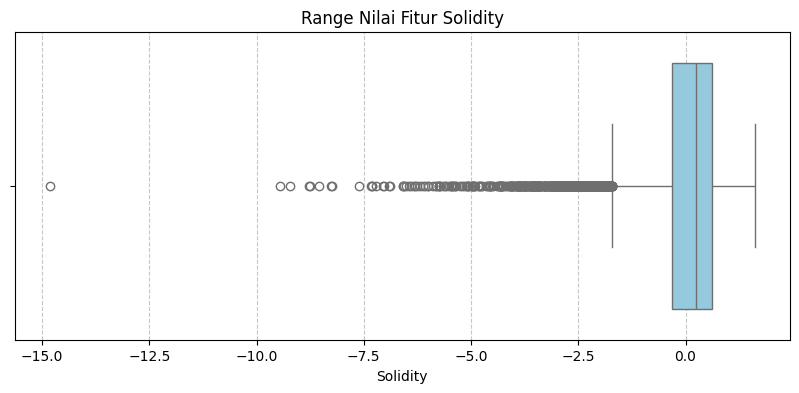

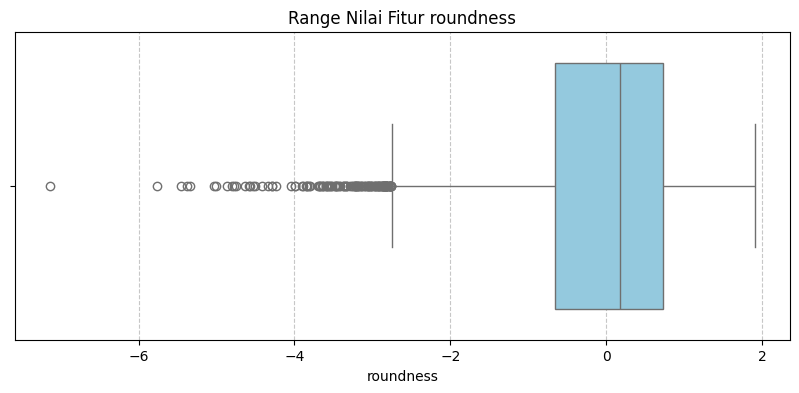

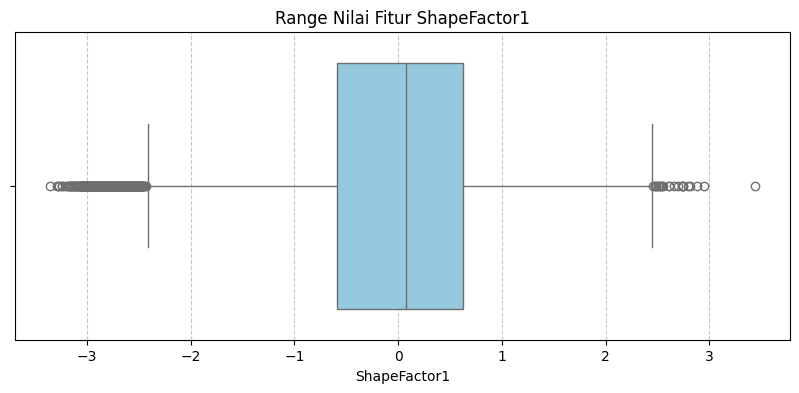

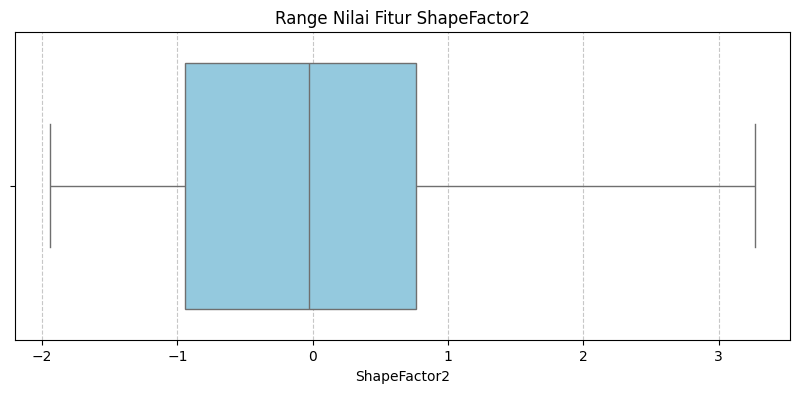

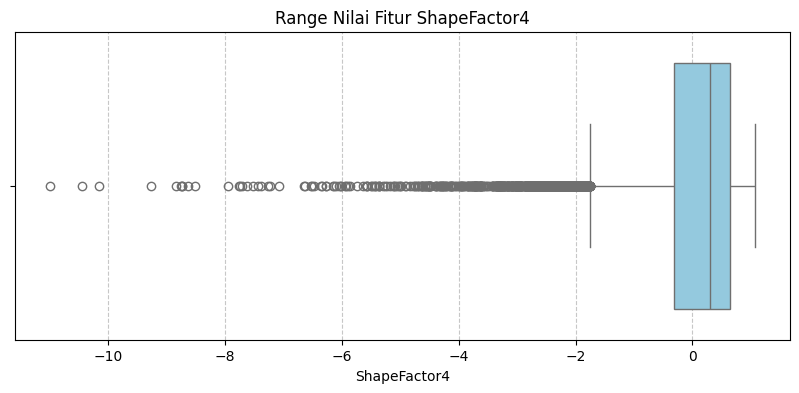

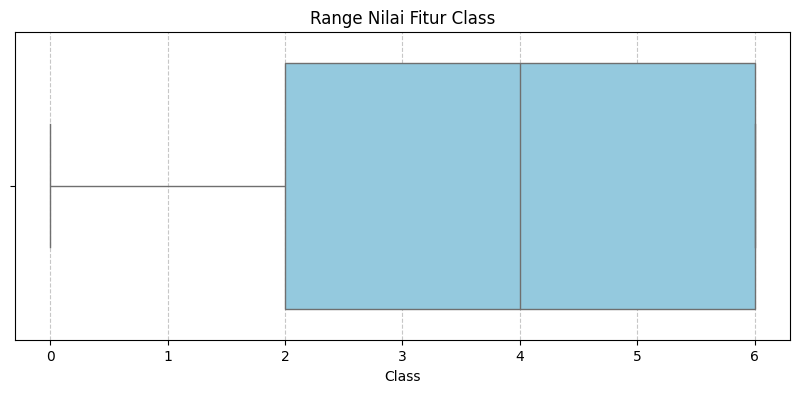

In [24]:
for col in bean:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=bean[col], color='skyblue') 
    plt.title(f'Range Nilai Fitur {col}')
    plt.grid(axis='x', linestyle='--', alpha=0.7)
    plt.show()

## 4. Model

### 4.1 Split Data

In [25]:
def split_data(X, y, size=0.8):
    np.random.seed(42)

    x_train, x_test = [], []
    y_train, y_test = [], []

    for class_values in np.unique(y):
        class_idx = np.where(y == class_values)[0]

        idx = np.random.permutation(class_idx)
        split = int(len(idx) * size)

        x_train.append(X.iloc[idx[:split]])
        x_test.append(X.iloc[idx[split:]])
        y_train.append(y.iloc[idx[:split]])
        y_test.append(y.iloc[idx[split:]])

    X_train = pd.concat(x_train).reset_index(drop=True)
    X_test = pd.concat(x_test).reset_index(drop=True)
    y_train = pd.concat(y_train).reset_index(drop=True)
    y_test = pd.concat(y_test).reset_index(drop=True)

    return X_train, X_test, y_train, y_test

In [26]:
X_train, X_test, y_train, y_test = split_data(X, y)

In [27]:
for var in [X_train, X_test, y_train, y_test]:
    print(var.shape)

(10831, 9)
(2712, 9)
(10831,)
(2712,)


In [28]:
mean_train = X_train.mean()
std_train = X_train.std()

X_train = (X_train - mean_train) / std_train
X_test = (X_test - mean_train) / std_train

### 4.2 K - Dimesional Tree (Class)

In [29]:
class Node:
    def __init__(self, point, label, left=None, right=None, axis=0):
        self.point = np.array(point)
        self.label = label
        self.left = left
        self.right = right
        self.axis = axis

class kdtree:
    def __init__(self, k_dimension):
        self.root = None
        self.k_dimension = k_dimension

    def build(self, point, label, depth=0):
        n = len(point)
        if n == 0:
            return None
        
        axis = depth % self.k_dimension

        sorted_indicies = np.argsort(point[:, axis])
        point = point[sorted_indicies]
        label = label[sorted_indicies]

        median = n // 2

        return Node(
            point = point[median],
            label = label[median],
            left = self.build(point[:median], label[:median], depth + 1),
            right = self.build(point[median+1:], label[median+1:], depth + 1),
            axis = axis 
        )

    def fit(self, X, y):
        self.root = self.build(np.array(X), np.array(y))
        return self

    def _search_nearest(self, node,target, best=None):
        if node is None:
            return best
        
        dist = np.sum((node.point - target) ** 2)

        if best is None or dist < best[0]:
            best = (dist, node.point, node.label)

        diff = target[node.axis] - node.point[point.axis]
        first = node.left if diff < 0 else node.right
        second = node.right if diff < 0 else node.left

        best = self._search_nearest(first, target, best)

        if best[0] > diff ** 2:
            best = self._search_nearest(second, target, best)

        return best

    def nearest_neighbor(self, point):
        result = self._search_nearest(self.root, np.array(point))
        return result[1], result[2]

    def _search_k_nearest(self, node, target, heap, k):
        if node is None:
            return heap

        dist = float(np.sum((node.point - target) ** 2))

        if len(heap) < k:
            heap.append((dist, node.point.copy(), node.label))
        elif dist < heap[0][0]:
            heap[0] = (dist, node.point.copy(), node.label)
            distances = np.array([h[0] for h in heap])
            sorted_indices = np.argsort(distances)[::-1]
            heap = [heap[i] for i in sorted_indices]

        diff = target[node.axis] - node.point[node.axis]
        first = node.left if diff < 0 else node.right
        second = node.right if diff < 0 else node.left

        heap = self._search_k_nearest(first, target, heap, k)

        if len(heap) < k or heap[0][0] > diff ** 2:
            heap = self._search_k_nearest(second, target, heap, k)
        
        return heap

    def k_nearest_neighbors(self, point, k=3):
        point = np.array(point, dtype=float)
        heap = self._search_k_nearest(self.root, np.array(point), [], k)

        distances = np.array([h[0] for h in heap])
        sorted_indices = np.argsort(distances)
        heap = [heap[i] for i in sorted_indices]
        
        return [(p, label) for (_, p, label) in heap]
        

### 4.3 K - Nearest Neighbours (Class)

In [30]:
class KNN:
    def __init__(self, n_neighbors=3):
        self.k = n_neighbors
        self.X_train = None
        self.y_train = None
    
    def fit(self, X, y):
        self.X_train = np.array(X, dtype=float)
        self.y_train = np.array(y)
        return self

    def predict(self, X_test):
        X_test = np.array(X_test, dtype=float)
        predictions = []
        
        for x in X_test:
            distances = np.sum((self.X_train - x) ** 2, axis=1)
            
            k_indices = np.argpartition(distances, self.k)[:self.k]
            k_labels = self.y_train[k_indices]
          
            unique, counts = np.unique(k_labels, return_counts=True)
            predictions.append(unique[np.argmax(counts)])
            
        return np.array(predictions)

    def score(self, X, y):
        prediction = self.predict(X)
        return np.mean(prediction == y)

### 4.4 Resampling (Function)

#### SMOTE 

In [31]:
def SMOTE(X, y, k=5):
    np.random.seed(42)

    counts = y.value_counts()
    minority_class = counts.idxmin()

    X_np = X.values
    y_np = y.values

    minority_X = X_np[y_np == minority_class]
    n_synthethic = counts.max() - counts.min()

    synthethic_samples = []

    for _ in range(n_synthethic):
        idx = np.random.randint(0, len(minority_X))
        sample = minority_X[idx]

        distances = np.sqrt(np.sum((minority_X - sample)**2, axis=1))
        nn_indicies = np.argsort(distances)[1:k+1]
        nn_idx = np.random.choice(nn_indicies)
        neighboor = minority_X[nn_idx]

        gap = np.random.rand()
        synthethic_samples.append(sample + gap * (neighboor - sample))

    X_balanced = np.vstack((X_np, synthethic_samples))
    y_balanced = np.hstack((y_np, np.full(n_synthethic, minority_class)))
    shuffle_idx = np.random.permutation(len(y_balanced))
    
    X_smote = pd.DataFrame(X_balanced[shuffle_idx], columns=X.columns)
    y_smote = pd.Series(y_balanced[shuffle_idx], name=y.name)
    
    return X_smote, y_smote

#### Noise Injection

In [32]:
def noise_injection(X, y, noise_factor=0.1):
    np.random.seed(42)

    counts = y.value_counts()
    minority_class = counts.idxmin()

    X_np = X.values
    y_np = y.values

    minority_X = X_np[y_np == minority_class]
    n_synthetic = counts.max() - counts.min()

    indicies = np.random.choice(len(minority_X), n_synthetic, replace=True)
    base_sample = minority_X[indicies]

    std_devs = np.std(X_np, axis=0) * noise_factor
    noise = np.random.normal(0, std_devs, base_sample.shape)

    noisy_sample = base_sample + noise

    X_balanced = np.vstack((X_np, noisy_sample))
    y_balanced = np.hstack((y_np, np.full(n_synthetic, minority_class)))

    shuffle_idx = np.random.permutation(len(y_balanced))

    X_noise = pd.DataFrame(X_balanced[shuffle_idx], columns=X.columns)
    y_noise = pd.Series(y_balanced[shuffle_idx], name=y.name)

    return X_noise, y_noise

#### Random Oversampling

In [33]:
def random_oversampling(X, y):
    np.random.seed(42)

    counts = y.value_counts()
    max_count = counts.max()
    target_names = counts.index

    X_balanced_list = []
    y_balanced_list = []

    for class_name in target_names:
        X_class = X[y == class_name]
        y_class = y[y == class_name]
        
        # Lakukan resampling agar jumlah tiap kelas sama dengan max_count
        indices = np.random.choice(len(X_class), max_count, replace=True)
        
        X_balanced_list.append(X_class.iloc[indices])
        y_balanced_list.append(y_class.iloc[indices])

    # Gabungkan semua kelas yang sudah seimbang
    X_balanced = pd.concat(X_balanced_list).reset_index(drop=True)
    y_balanced = pd.concat(y_balanced_list).reset_index(drop=True)

    # Shuffle agar urutan kelas acak
    shuffle_idx = np.random.permutation(len(y_balanced))
    
    return X_balanced.iloc[shuffle_idx], y_balanced.iloc[shuffle_idx]

#### Search the Best K (Function)

In [34]:
def search_k(X_train, y_train, X_test):
    best_acc = 0
    best_params = {'k': 0, 'p': 0}
    
    for k in [3,5,7,9,11,13,15]:
        for p in [1,2]:
            model = KNN(n_neighbors=k) 
            model.fit(X_train, y_train)
            acc = model.score(X_test.values, y_test)
            
            dist_name = 'manhattan' if p == 1 else 'euclidean'
            print(f'K: {k} - Distance: {dist_name} - Accuracy: {acc:.4f}')
            
            if acc > best_acc:
                best_acc = acc
                best_params = {'k': k, 'p': p}
                
    final_dist = 'manhattan' if best_params['p'] == 1 else 'euclidean'
    print(f'--- FINAL BEST: K={best_params["k"]}, Distance={final_dist}, Acc={best_acc:.4f} ---')
    return best_params

### 4.5 Implementation

#### Resampling

In [35]:
X_train_smote, y_train_smote = SMOTE(X_train, y_train)

In [36]:
X_train_noise, y_train_noise = noise_injection(X_train, y_train)

In [37]:
X_train_ros, y_train_ros = random_oversampling(X_train, y_train)

#### Search K

In [38]:
# Reguler
best_k = search_k(X_train, y_train, X_test)

K: 3 - Distance: manhattan - Accuracy: 0.9163
K: 3 - Distance: euclidean - Accuracy: 0.9163
K: 5 - Distance: manhattan - Accuracy: 0.9207
K: 5 - Distance: euclidean - Accuracy: 0.9207
K: 7 - Distance: manhattan - Accuracy: 0.9207
K: 7 - Distance: euclidean - Accuracy: 0.9207
K: 9 - Distance: manhattan - Accuracy: 0.9255
K: 9 - Distance: euclidean - Accuracy: 0.9255
K: 11 - Distance: manhattan - Accuracy: 0.9229
K: 11 - Distance: euclidean - Accuracy: 0.9229
K: 13 - Distance: manhattan - Accuracy: 0.9237
K: 13 - Distance: euclidean - Accuracy: 0.9237
K: 15 - Distance: manhattan - Accuracy: 0.9218
K: 15 - Distance: euclidean - Accuracy: 0.9218
--- FINAL BEST: K=9, Distance=manhattan, Acc=0.9255 ---


In [39]:
# SMOTE
best_k_smote = search_k(X_train_smote, y_train_smote, X_test)

K: 3 - Distance: manhattan - Accuracy: 0.9163
K: 3 - Distance: euclidean - Accuracy: 0.9163
K: 5 - Distance: manhattan - Accuracy: 0.9207
K: 5 - Distance: euclidean - Accuracy: 0.9207
K: 7 - Distance: manhattan - Accuracy: 0.9207
K: 7 - Distance: euclidean - Accuracy: 0.9207
K: 9 - Distance: manhattan - Accuracy: 0.9255
K: 9 - Distance: euclidean - Accuracy: 0.9255
K: 11 - Distance: manhattan - Accuracy: 0.9229
K: 11 - Distance: euclidean - Accuracy: 0.9229
K: 13 - Distance: manhattan - Accuracy: 0.9237
K: 13 - Distance: euclidean - Accuracy: 0.9237
K: 15 - Distance: manhattan - Accuracy: 0.9218
K: 15 - Distance: euclidean - Accuracy: 0.9218
--- FINAL BEST: K=9, Distance=manhattan, Acc=0.9255 ---


In [40]:
best_k_noise = search_k(X_train_noise, y_train_noise, X_test)

K: 3 - Distance: manhattan - Accuracy: 0.9163
K: 3 - Distance: euclidean - Accuracy: 0.9163
K: 5 - Distance: manhattan - Accuracy: 0.9207
K: 5 - Distance: euclidean - Accuracy: 0.9207
K: 7 - Distance: manhattan - Accuracy: 0.9207
K: 7 - Distance: euclidean - Accuracy: 0.9207
K: 9 - Distance: manhattan - Accuracy: 0.9255
K: 9 - Distance: euclidean - Accuracy: 0.9255
K: 11 - Distance: manhattan - Accuracy: 0.9229
K: 11 - Distance: euclidean - Accuracy: 0.9229
K: 13 - Distance: manhattan - Accuracy: 0.9237
K: 13 - Distance: euclidean - Accuracy: 0.9237
K: 15 - Distance: manhattan - Accuracy: 0.9218
K: 15 - Distance: euclidean - Accuracy: 0.9218
--- FINAL BEST: K=9, Distance=manhattan, Acc=0.9255 ---


In [41]:
best_k_ros = search_k(X_train_ros, y_train_ros, X_test)

K: 3 - Distance: manhattan - Accuracy: 0.9019
K: 3 - Distance: euclidean - Accuracy: 0.9019
K: 5 - Distance: manhattan - Accuracy: 0.9060
K: 5 - Distance: euclidean - Accuracy: 0.9060
K: 7 - Distance: manhattan - Accuracy: 0.9126
K: 7 - Distance: euclidean - Accuracy: 0.9126
K: 9 - Distance: manhattan - Accuracy: 0.9163
K: 9 - Distance: euclidean - Accuracy: 0.9163
K: 11 - Distance: manhattan - Accuracy: 0.9174
K: 11 - Distance: euclidean - Accuracy: 0.9174
K: 13 - Distance: manhattan - Accuracy: 0.9189
K: 13 - Distance: euclidean - Accuracy: 0.9189
K: 15 - Distance: manhattan - Accuracy: 0.9159
K: 15 - Distance: euclidean - Accuracy: 0.9159
--- FINAL BEST: K=13, Distance=manhattan, Acc=0.9189 ---


In [42]:
model = KNN(n_neighbors=3)
model.fit(X_train, y_train)

model_smote = KNN(n_neighbors=best_k_smote.get('k', 3))
model_smote.fit(X_train_smote, y_train_smote)

model_noise = KNN(n_neighbors=best_k_noise.get('k', 3))
model_noise.fit(X_train_noise, y_train_noise)

model_ros = KNN(n_neighbors=best_k_ros.get('k', 3)) # Menggunakan K terbaik hasil search
model_ros.fit(X_train_ros, y_train_ros)

In [43]:
# reguler
y_pred_train = model.predict(X_train.values)
y_pred_test = model.predict(X_test.values)

# Smote
y_pred_train_smote = model_smote.predict(X_train_smote.values)
y_pred_test_smote = model_smote.predict(X_test.values)

# Noise
y_pred_train_noise = model_noise.predict(X_train_noise.values)
y_pred_test_noise = model_noise.predict(X_test.values)

# Random Oversampling 
y_pred_train_ros = model_ros.predict(X_train_ros.values)
y_pred_test_ros = model_ros.predict(X_test.values)

## 5. Evaluation

### 5.1 Evaluation per Resample Techique

In [44]:
# Tambahkan parameter 'model' ke dalam fungsi
def evaluate(model, X_eval, y_eval, y_pred, title='Evaluation'):
    y_true = np.array(y_eval)
    y_pred = np.array(y_pred)

    classes = np.unique(y_true)
    
    # Menghitung Accuracy menggunakan model yang spesifik dipassing
    accuracy = model.score(X_eval.values, y_true)
    
    precision = []
    recall = []
    f1 = []

    for i in classes:
        tp = np.sum((y_true == i) & (y_pred == i))
        fp = np.sum((y_true != i) & (y_pred == i))
        fn = np.sum((y_true == i) & (y_pred != i))

        p = tp / (tp + fp) if (tp + fp) > 0 else 0
        r = tp / (tp + fn) if (tp + fn) > 0 else 0
        f = 2 * (p * r) / (p + r) if (p + r) > 0 else 0

        precision.append(p)
        recall.append(r)
        f1.append(f)

    # Macro Averaging
    m_precision = np.mean(precision)
    m_recall = np.mean(recall)
    m_f1 = np.mean(f1)

    print(f'--- {title} ---')
    print(f'Accuracy  : {accuracy:.2%}')
    print(f'Precision : {m_precision:.2%}')
    print(f'Recall    : {m_recall:.2%}')
    print(f'F1 Score  : {m_f1:.2%}\n')

In [45]:
#### 1. Regular
print("HASIL REGULAR")
evaluate(model, X_train, y_train, y_pred_train, title='Train Regular')
evaluate(model, X_test, y_test, y_pred_test, title='Test Regular')

HASIL REGULAR
--- Train Regular ---
Accuracy  : 95.11%
Precision : 95.82%
Recall    : 95.84%
F1 Score  : 95.83%

--- Test Regular ---
Accuracy  : 91.63%
Precision : 92.80%
Recall    : 92.86%
F1 Score  : 92.82%



In [46]:
#### 2. SMOTE
print("HASIL SMOTE")
evaluate(model_smote, X_train_smote, y_train_smote, y_pred_train_smote, title='Train SMOTE')
evaluate(model_smote, X_test, y_test, y_pred_test_smote, title='Test SMOTE')


HASIL SMOTE
--- Train SMOTE ---
Accuracy  : 94.60%
Precision : 94.70%
Recall    : 94.40%
F1 Score  : 94.54%

--- Test SMOTE ---
Accuracy  : 92.55%
Precision : 93.83%
Recall    : 93.46%
F1 Score  : 93.62%



In [47]:
#### 3. Noise
print("HASIL NOISE")
evaluate(model_noise, X_train_noise, y_train_noise, y_pred_train_noise, title='Train Noise')
evaluate(model_noise, X_test, y_test, y_pred_test_noise, title='Test Noise')


HASIL NOISE
--- Train Noise ---
Accuracy  : 94.60%
Precision : 94.70%
Recall    : 94.39%
F1 Score  : 94.53%

--- Test Noise ---
Accuracy  : 92.55%
Precision : 93.83%
Recall    : 93.46%
F1 Score  : 93.62%



In [48]:

#### 4. ROS
print("HASIL ROS")
evaluate(model_ros, X_train_ros, y_train_ros, y_pred_train_ros, title='Train ROS')
evaluate(model_ros, X_test, y_test, y_pred_test_ros, title='Test ROS')

HASIL ROS
--- Train ROS ---
Accuracy  : 95.03%
Precision : 95.08%
Recall    : 95.03%
F1 Score  : 95.04%

--- Test ROS ---
Accuracy  : 91.89%
Precision : 92.95%
Recall    : 93.01%
F1 Score  : 92.97%



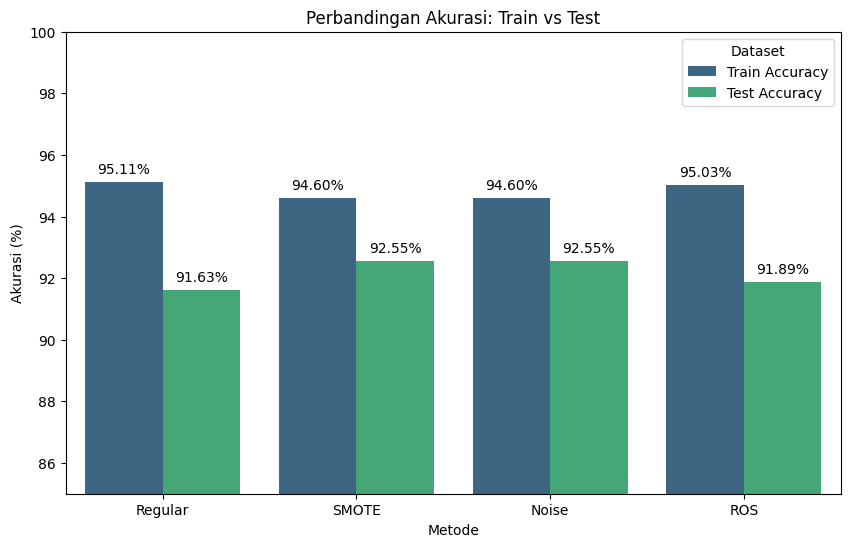

In [49]:

data = {
    'Metode': ['Regular', 'SMOTE', 'Noise', 'ROS'],
    'Train Accuracy': [95.11, 94.60, 94.60, 95.03],
    'Test Accuracy': [91.63, 92.55, 92.55, 91.89]
}

df_plot = pd.DataFrame(data)
df_melted = df_plot.melt(id_vars='Metode', var_name='Dataset', value_name='Accuracy')

plt.figure(figsize=(10, 6))
sns.barplot(data=df_melted, x='Metode', y='Accuracy', hue='Dataset', palette='viridis')
plt.ylim(85, 100) # Zoom agar perbedaan terlihat jelas
plt.title('Perbandingan Akurasi: Train vs Test')
plt.ylabel('Akurasi (%)')
for p in plt.gca().patches:
    plt.gca().annotate(f'{p.get_height():.2f}%', (p.get_x() + p.get_width() / 2., p.get_height()), 
                       ha='center', va='center', xytext=(0, 9), textcoords='offset points')
plt.show()

### 5.2 Confusion Matrix

In [50]:
def confusion_matrix(y_train, y_pred_train, y_test, y_pred_test, title=''):
    classes = np.unique(y)
    n_classes = len(classes)

    fig, axes = plt.subplots(1,2, figsize=(8,6))
    plt.suptitle(f'Evaluasi Data {title}', fontsize=26)
    fig.supxlabel('Prediksi')
    fig.supylabel('Aktual')
    

    cm_train = np.zeros((n_classes, n_classes))
    for i, c_true in enumerate(classes):
        for j, c_pred in enumerate(classes):
            cm_train[i,j] = np.sum((y_train == c_true) * (y_pred_train == c_pred))
    sns.heatmap(cm_train, annot=True, fmt='.0f', cmap='Blues', ax=axes[0], cbar=False)

    cm_test = np.zeros((n_classes, n_classes))
    for a, a_true in enumerate(classes):
        for b, a_pred in enumerate(classes):
            cm_test[a,b] = np.sum((y_test == a_true) * (y_pred_test == a_pred))
    sns.heatmap(cm_test, annot=True, fmt='.0f', cmap='Blues', ax=axes[1], cbar=False)

    plt.tight_layout()
    plt.show()

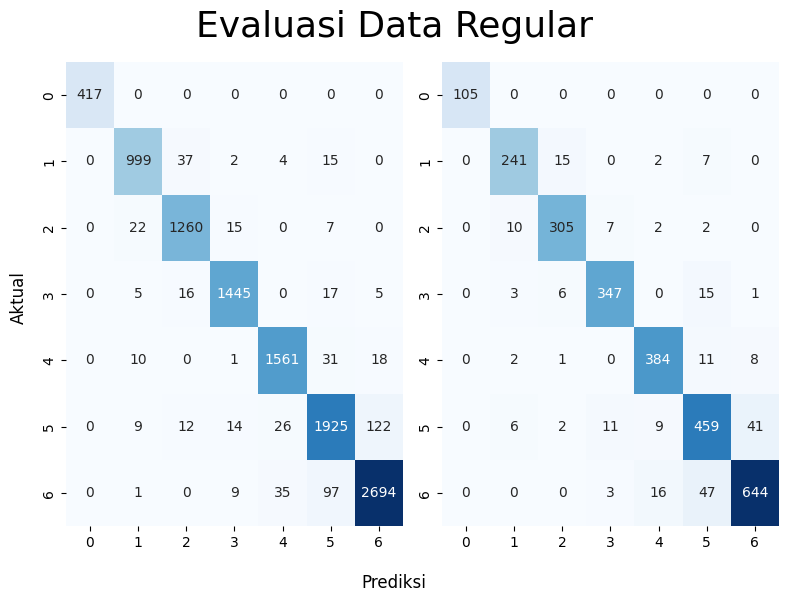

In [51]:
confusion_matrix(y_train, y_pred_train, y_test, y_pred_test, title='Regular')

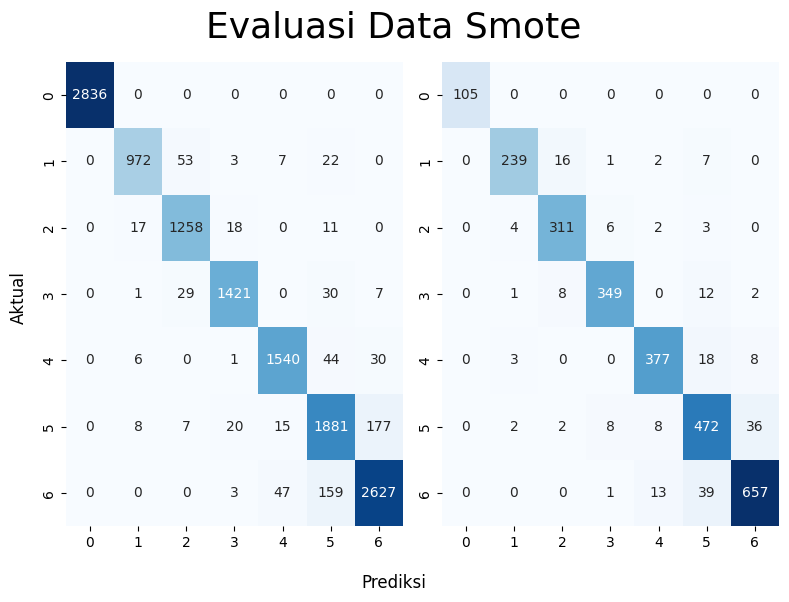

In [52]:
confusion_matrix(y_train_smote, y_pred_train_smote, y_test, y_pred_test_smote, title='Smote')

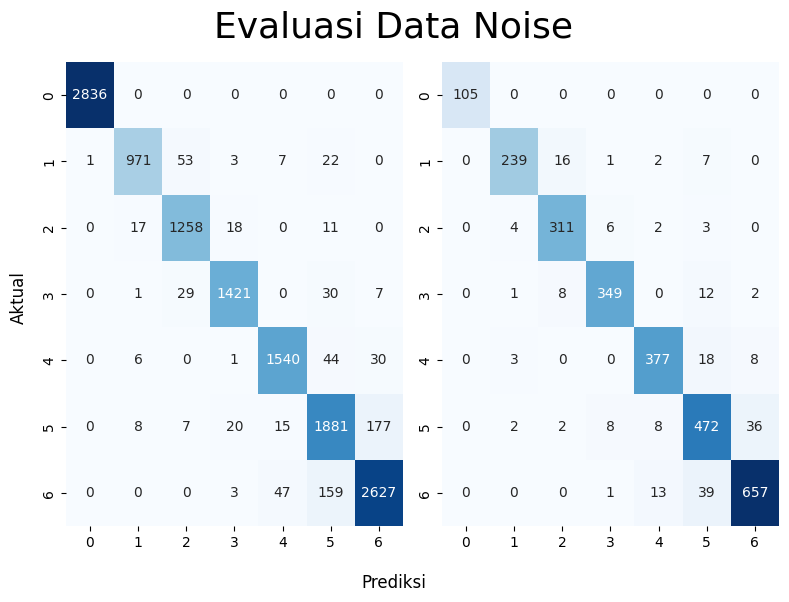

In [53]:
confusion_matrix(y_train_noise, y_pred_train_noise, y_test, y_pred_test_noise, title='Noise')

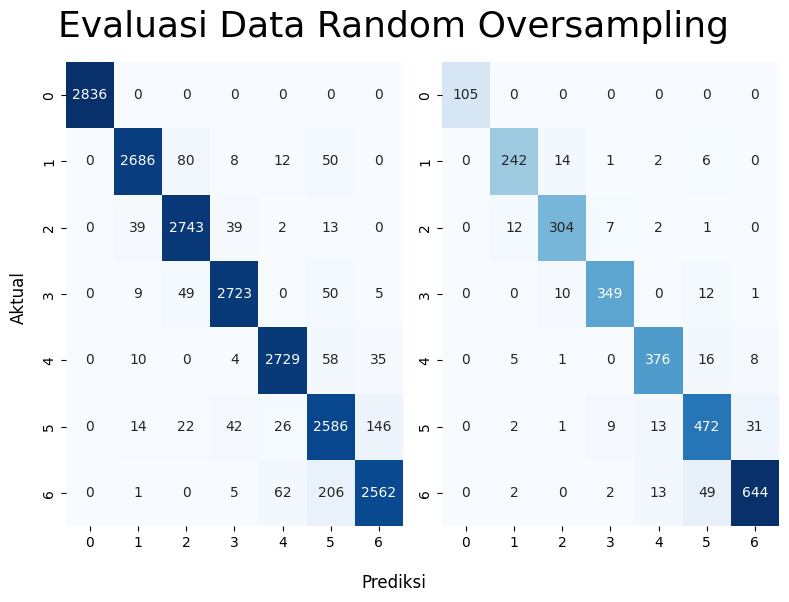

In [54]:
confusion_matrix(y_train_ros, y_pred_train_ros, y_test, y_pred_test_ros, title='Random Oversampling')

## 6. Visualization

In [ ]:
# def visualize_neighbor_search(model, X_train, target_point, k=5):
#     # Cari k-tetangga terdekat menggunakan fungsi KD-Tree Anda
#     neighbors = model.k_nearest_neighbors(target_point, k=k)
    
#     plt.figure(figsize=(8, 6))
#     # Plot semua data training (hanya 2 dimensi)
#     plt.scatter(X_train.iloc[:, 0], X_train.iloc[:, 1], alpha=0.3, label='Data Training', c='gray')
    
#     # Plot target point (data yang ingin diprediksi)
#     plt.scatter(target_point[0], target_point[1], c='red', marker='*', s=200, label='Target')
    
#     # Plot tetangga yang ditemukan dan garis penghubungnya
#     for p, label in neighbors:
#         plt.plot([target_point[0], p[0]], [target_point[1], p[1]], 'k--', alpha=0.6)
#         plt.scatter(p[0], p[1], c='blue', s=100)
    
#     plt.title(f"Visualisasi Pencarian {k} Tetangga Terdekat")
#     plt.legend()
#     plt.show()

# # Ambil satu contoh data dari X_test sebagai target
# sample_target = X_test.iloc[0].values
# visualize_neighbor_search(model_kdtree, X_train, sample_target, k=15)

NameError: name 'model_kdtree' is not defined

## 7. GUI

In [60]:
feature = X.columns
n_feature = len(feature)

def submit():
    try:
        input_data = []
        for entry in entries:
            value = float(entry.get())
            input_data.append(value)

        input_df = pd.DataFrame([input_data], columns=feature)
        input_scaled = (input_df - X.mean()) / X.std()
        prediction = model_noise.predict(input_scaled.values)
        messagebox.showinfo('Prediksi Model', f'Model Menebak Kacang: {prediction}')
    except ValueError:
        messagebox.showerror('Input Error', 'Masukan Value Yang Benar ⚠️')
        
root = tk.Tk()
root.configure(bg='#9ECFD4')
root.title('Prediksi Jenis Kacang')
entries = []

title_label = tk.Label(root, text='Prediksi Jenis Kacang', font=('Arial', 26, 'bold'), bg='#9ECFD4')
title_label.grid(row=0, column=0, columnspan=2, padx=25, pady=10)
for i, col in enumerate(feature):
    label = tk.Label(root, text=f'{col}:', bg='#9ECFD4')
    label.grid(row=i+1, column=0, padx=20, pady=5, sticky='w')

    entry = tk.Entry(bg='#7db0b5')
    entry.grid(row=i+1, column=1, padx=20, pady=5)
    entries.append(entry)

submit_btn = tk.Button(root, text='Prediksi', command=submit, bg='#B8DB80')
submit_btn.grid(row=n_feature+1, column=0, columnspan=2, pady=20, ipady=5)

root.mainloop()

In [57]:
bean.sample(5)

,Area,AspectRation,Eccentricity,Extent,Solidity,roundness,ShapeFactor1,ShapeFactor2,ShapeFactor4,Class
3783,3.418232,0.314478,0.484999,1.099223,0.211201,-0.089330,-2.909506,-1.649044,-0.172908,0
12051,-0.906717,-1.028608,-0.926913,-0.398580,0.225554,0.748755,0.550905,1.254134,0.094668,6
2482,0.768362,-0.084026,0.169308,-0.633309,0.235353,-0.468027,-0.957758,-0.536414,0.504442,1
10527,-1.400026,-0.431630,-0.165400,-0.380870,0.850241,1.023197,1.561184,1.104310,0.850936,6
2570,0.832319,-0.810387,-0.614894,-0.348495,-0.606732,-0.528515,-1.283026,-0.141110,0.094206,1


## 8. Conclution

- Nilai target imbalance atau tidak seimbang 